Imports and Data Loading

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [79]:
train_data = pd.read_csv('train.csv')
val_data = pd.read_csv('val.csv')

train_data["trip_duration"]=np.log1p(train_data['trip_duration'])
val_data["trip_duration"]=np.log1p(val_data['trip_duration'])



In [80]:
train_data_copy = train_data.copy()
target_train_value=train_data["trip_duration"]
val_data_copy = val_data.copy()
target_val_value=val_data["trip_duration"]


Explore train dataset

In [81]:
train_data_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1000000.0,1.534793,0.498788,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-61.335529
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,51.881084
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-61.335529
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,43.921028
trip_duration,1000000.0,6.466492,0.794744,0.693147,5.986452,6.496775,6.980076,14.616441


In [82]:
val_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229319 entries, 0 to 229318
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  229319 non-null  object 
 1   vendor_id           229319 non-null  int64  
 2   pickup_datetime     229319 non-null  object 
 3   passenger_count     229319 non-null  int64  
 4   pickup_longitude    229319 non-null  float64
 5   pickup_latitude     229319 non-null  float64
 6   dropoff_longitude   229319 non-null  float64
 7   dropoff_latitude    229319 non-null  float64
 8   store_and_fwd_flag  229319 non-null  object 
 9   trip_duration       229319 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 17.5+ MB


In [83]:
train_data_copy.duplicated().sum()

np.int64(0)

In [84]:
train_data_copy.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

EDA && Feature Engineering


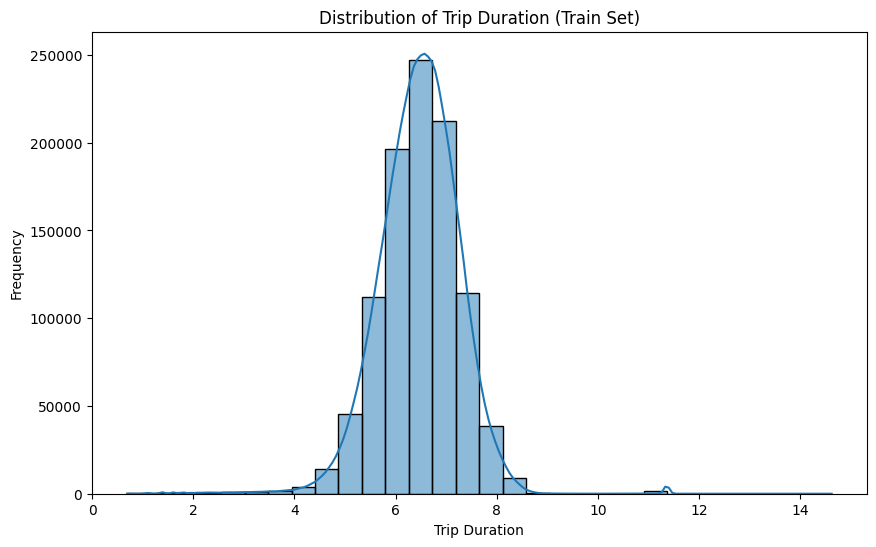

In [85]:
#plot the distribution of the target variable
plt.figure(figsize=(10,6))
sns.histplot(train_data_copy["trip_duration"], bins=30, kde=True)
plt.title("Distribution of Trip Duration (Train Set)")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.show()

remove the id feature (because it does not affect)

In [86]:
train_data_copy=train_data_copy.drop(columns="id")
val_data_copy=val_data_copy.drop(columns="id")

let's check the `vendor id` importance and its corrliation with the target

In [87]:
train_data_copy["vendor_id"].value_counts()

vendor_id
2    534793
1    465207
Name: count, dtype: int64

vendor_id
1    6.449957
2    6.480875
Name: trip_duration, dtype: float64

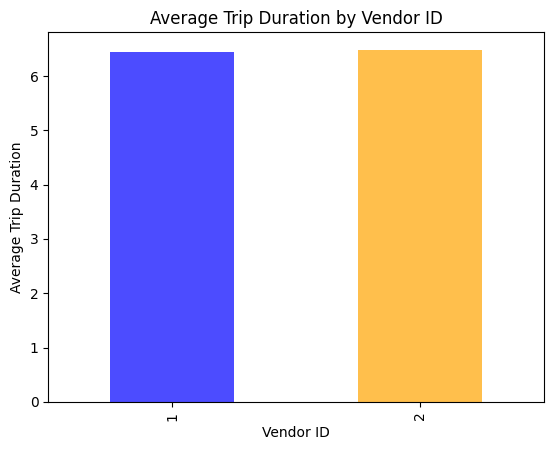

In [88]:
#plot the mean of each value of vendor id with respect to the trip duration
vendor_avg=train_data_copy.groupby("vendor_id")["trip_duration"].mean()
vendor_avg.plot(kind="bar", title="Average Trip Duration by Vendor ID", ylabel="Average Trip Duration", xlabel="Vendor ID", color=["blue", "orange"],alpha=0.7)
vendor_avg

In [89]:
from scipy.stats import ttest_ind

vendor1=train_data_copy.loc[train_data_copy["vendor_id"]==1,"trip_duration"]
vendor2=train_data_copy.loc[train_data_copy["vendor_id"]==2,"trip_duration"]


t_stat, p_val = ttest_ind(vendor1, vendor2, equal_var=False)  # Welch’s t-test
print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: -19.435377355287567
p-value: 4.019048259697505e-84


t-statistic: -19.435377355287567
→ Negative means vendor2 has a larger mean trip duration than vendor1.
→ The magnitude (29!) is enormous — the difference is not just small random fluctuation.

p-value:  4.019048259697505e-84
→ That’s basically 0.
→ Far below any reasonable threshold (0.05, 0.01, 0.001).
→ The difference between vendor 1 and vendor 2 trip durations is highly statistically significant.

in short: 
Vendor 2 trips take significantly longer on average than Vendor 1 trips, and this is not due to chance. This makes vendor_id a very strong feature for predicting trip duration

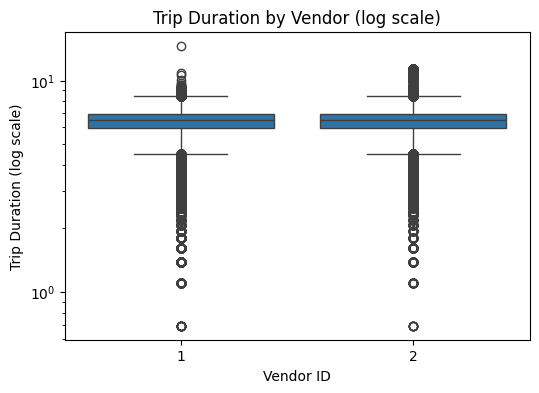

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="vendor_id", y="trip_duration", data=train_data_copy)

# Apply log scale to y-axis
plt.yscale("log")

plt.title("Trip Duration by Vendor (log scale)")
plt.xlabel("Vendor ID")
plt.ylabel("Trip Duration (log scale)")
plt.show()


After checking the importance of the vendor id , we decide to apply the binary encoding

In [91]:
train_data_copy["is_vendor2"] = (train_data_copy["vendor_id"] == 2).astype(int)
val_data_copy["is_vendor2"] = (val_data_copy["vendor_id"] == 2).astype(int)



print(train_data_copy[["vendor_id", "is_vendor2"]].head())


   vendor_id  is_vendor2
0          2           1
1          2           1
2          2           1
3          2           1
4          1           0


In [92]:
train_data_copy=train_data_copy.drop(columns="vendor_id",axis=1)


In [93]:
val_data_copy=val_data_copy.drop(columns="vendor_id",axis=1)

In [94]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   pickup_datetime     1000000 non-null  object 
 1   passenger_count     1000000 non-null  int64  
 2   pickup_longitude    1000000 non-null  float64
 3   pickup_latitude     1000000 non-null  float64
 4   dropoff_longitude   1000000 non-null  float64
 5   dropoff_latitude    1000000 non-null  float64
 6   store_and_fwd_flag  1000000 non-null  object 
 7   trip_duration       1000000 non-null  float64
 8   is_vendor2          1000000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 68.7+ MB


Let's check passenger count feature and its effect

<Axes: xlabel='passenger_count', ylabel='trip_duration'>

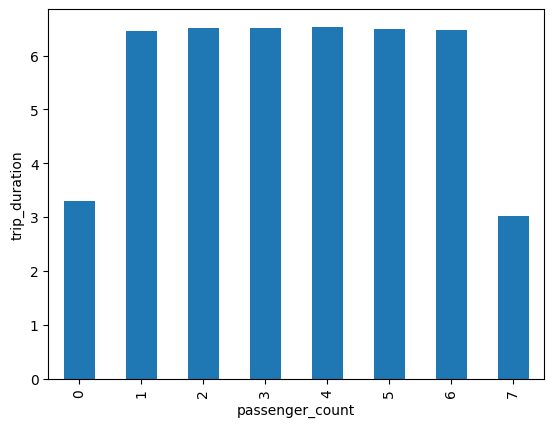

In [95]:
train_data_copy.groupby("passenger_count")["trip_duration"].mean().plot(kind="bar",xlabel="passenger_count",ylabel="trip_duration")

just remove the outliers

In [96]:
train_data_copy=train_data_copy[(train_data_copy["passenger_count"]>0)&(train_data_copy["passenger_count"]<=6)]
val_data_copy=val_data_copy[(val_data_copy["passenger_count"]>0)&(val_data_copy["passenger_count"]<=6)]

In [97]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pickup_datetime     999960 non-null  object 
 1   passenger_count     999960 non-null  int64  
 2   pickup_longitude    999960 non-null  float64
 3   pickup_latitude     999960 non-null  float64
 4   dropoff_longitude   999960 non-null  float64
 5   dropoff_latitude    999960 non-null  float64
 6   store_and_fwd_flag  999960 non-null  object 
 7   trip_duration       999960 non-null  float64
 8   is_vendor2          999960 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 76.3+ MB


let's analyze the `store_and_fwd_flag` feature

C:\Users\Mahmoud Nashaat\AppData\Local\Temp\ipykernel_21592\1984927608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="store_and_fwd_flag", data=train_data_copy, palette=["green", "red"])


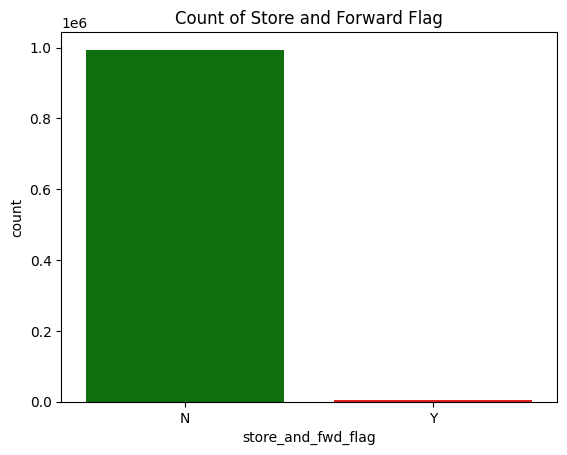

store_and_fwd_flag
N    994405
Y      5555
Name: count, dtype: int64

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="store_and_fwd_flag", data=train_data_copy, palette=["green", "red"])
plt.title("Count of Store and Forward Flag")
plt.show()
train_data_copy["store_and_fwd_flag"].value_counts()

`store_and_fwd_flag` is highly imbalanced (≈99.5% N vs 0.5% Y) with only a tiny duration difference, so it adds little value and can be dropped. 


In [99]:
train_data_copy=train_data_copy.drop(["store_and_fwd_flag"], axis=1)
val_data_copy=val_data_copy.drop(["store_and_fwd_flag"], axis=1)

In [100]:
train_data_copy.info()
val_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    999960 non-null  object 
 1   passenger_count    999960 non-null  int64  
 2   pickup_longitude   999960 non-null  float64
 3   pickup_latitude    999960 non-null  float64
 4   dropoff_longitude  999960 non-null  float64
 5   dropoff_latitude   999960 non-null  float64
 6   trip_duration      999960 non-null  float64
 7   is_vendor2         999960 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 68.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 229304 entries, 0 to 229318
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    229304 non-null  object 
 1   passenger_count    229304 non-null  int64  
 2   pickup_longitude   229304 non-null  

Handling the datatime features

In [101]:
train_data_copy["pickup_datetime"] = pd.to_datetime(train_data_copy["pickup_datetime"])
val_data_copy["pickup_datetime"] = pd.to_datetime(val_data_copy["pickup_datetime"])


In [102]:
def extract_datetime_features(df, col):
    df[f"{col}_month"] = df[col].dt.month
    df[f"{col}_day"] = df[col].dt.day
    df[f"{col}_hour"] = df[col].dt.hour
    df[f"{col}_day_of_week"] = df[col].dt.dayofweek
    df[f"{col}_is_weekend"] = df[f"{col}_day_of_week"].isin([5, 6]).astype(int)

    # cyclical encoding
    df[f"{col}_hour_sin"] = np.sin(2 * np.pi * df[f"{col}_hour"] / 24)
    df[f"{col}_hour_cos"] = np.cos(2 * np.pi * df[f"{col}_hour"] / 24)

    df[f"{col}_dow_sin"] = np.sin(2 * np.pi * df[f"{col}_day_of_week"] / 7)
    df[f"{col}_dow_cos"] = np.cos(2 * np.pi * df[f"{col}_day_of_week"] / 7)
    df.drop(col, axis=1, inplace=True)
    return df



In [103]:
extract_datetime_features(train_data_copy,"pickup_datetime")
extract_datetime_features(val_data_copy,"pickup_datetime")


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,is_vendor2,pickup_datetime_month,pickup_datetime_day,pickup_datetime_hour,pickup_datetime_day_of_week,pickup_datetime_is_weekend,pickup_datetime_hour_sin,pickup_datetime_hour_cos,pickup_datetime_dow_sin,pickup_datetime_dow_cos
0,1,-74.013916,40.713444,-73.993858,40.752510,7.130899,0,1,10,16,6,1,-0.866025,-5.000000e-01,-0.781831,0.623490
1,1,-74.005440,40.727306,-73.983063,40.734715,6.706862,0,6,23,18,3,0,-1.000000,-1.836970e-16,0.433884,-0.900969
2,1,-73.987587,40.749863,-73.986809,40.757549,5.905362,0,5,14,21,5,1,-0.707107,7.071068e-01,-0.974928,-0.222521
3,1,-73.973862,40.784153,-73.983025,40.774479,5.278115,1,5,2,20,0,0,-0.866025,5.000000e-01,0.000000,1.000000
4,1,-73.999916,40.733101,-74.008331,40.734177,5.648974,0,5,19,10,3,0,0.500000,-8.660254e-01,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229314,1,-73.988518,40.737137,-73.983948,40.765041,6.878326,0,1,22,22,4,0,-0.500000,8.660254e-01,-0.433884,-0.900969
229315,2,-74.006371,40.733372,-73.975792,40.782909,6.845880,1,2,23,22,1,0,-0.500000,8.660254e-01,0.781831,0.623490
229316,1,-74.013237,40.716980,-74.001297,40.734604,6.188264,0,2,20,16,5,1,-0.866025,-5.000000e-01,-0.974928,-0.222521
229317,1,-73.978394,40.748280,-73.982002,40.736580,5.598422,1,3,29,19,1,0,-0.965926,2.588190e-01,0.781831,0.623490


In [104]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   trip_duration                999960 non-null  float64
 6   is_vendor2                   999960 non-null  int64  
 7   pickup_datetime_month        999960 non-null  int32  
 8   pickup_datetime_day          999960 non-null  int32  
 9   pickup_datetime_hour         999960 non-null  int32  
 10  pickup_datetime_day_of_week  999960 non-null  int32  
 11  pickup_datetime_is_weekend   999960 non-null  int64  
 12  pickup_datetime_hour_sin     999960 non-null  float64
 13  pick

Check seamolity : to apply cycle encodeing


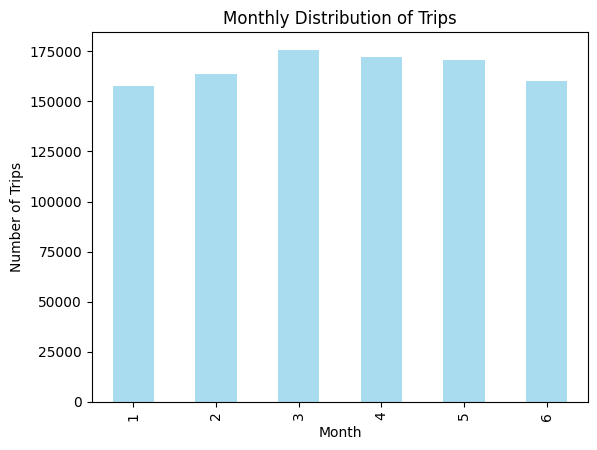

In [105]:
# plot the monthly distribution of trip duration
train_data_copy["pickup_datetime_month"].value_counts().sort_index().plot(kind="bar", title="Monthly Distribution of Trips", xlabel="Month", ylabel="Number of Trips", color="skyblue", alpha=0.7)
plt.show()

Handling the distance using latttude and longtitude

In [106]:
# compute the distance using the haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth radius in km
    return c * r

train_data_copy["trip_distance_km"] = haversine_distance(
    train_data_copy["pickup_latitude"],
    train_data_copy["pickup_longitude"],
    train_data_copy["dropoff_latitude"],
    train_data_copy["dropoff_longitude"]
)

val_data_copy["trip_distance_km"] = haversine_distance(
    val_data_copy["pickup_latitude"],
    val_data_copy["pickup_longitude"],
    val_data_copy["dropoff_latitude"],
    val_data_copy["dropoff_longitude"]
)


In [107]:
# train_data_copy=train_data_copy.drop(columns=["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"], axis=1)
# val_data_copy=val_data_copy.drop(columns=["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"], axis=1)

In [108]:
train_data_copy["trip_distance_km"]=np.log1p(train_data_copy["trip_distance_km"])
val_data_copy["trip_distance_km"]=np.log1p(val_data_copy["trip_distance_km"])

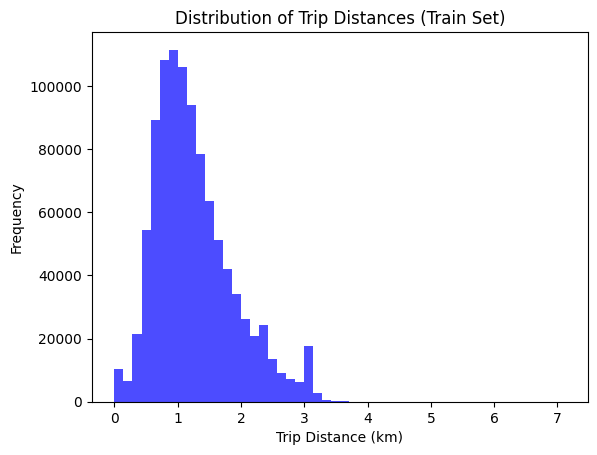

In [109]:
plt.hist(train_data_copy["trip_distance_km"], bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Trip Distances (Train Set)")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Frequency")
plt.show()


In [110]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   trip_duration                999960 non-null  float64
 6   is_vendor2                   999960 non-null  int64  
 7   pickup_datetime_month        999960 non-null  int32  
 8   pickup_datetime_day          999960 non-null  int32  
 9   pickup_datetime_hour         999960 non-null  int32  
 10  pickup_datetime_day_of_week  999960 non-null  int32  
 11  pickup_datetime_is_weekend   999960 non-null  int64  
 12  pickup_datetime_hour_sin     999960 non-null  float64
 13  pick

In [111]:
val_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229304 entries, 0 to 229318
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              229304 non-null  int64  
 1   pickup_longitude             229304 non-null  float64
 2   pickup_latitude              229304 non-null  float64
 3   dropoff_longitude            229304 non-null  float64
 4   dropoff_latitude             229304 non-null  float64
 5   trip_duration                229304 non-null  float64
 6   is_vendor2                   229304 non-null  int64  
 7   pickup_datetime_month        229304 non-null  int32  
 8   pickup_datetime_day          229304 non-null  int32  
 9   pickup_datetime_hour         229304 non-null  int32  
 10  pickup_datetime_day_of_week  229304 non-null  int32  
 11  pickup_datetime_is_weekend   229304 non-null  int64  
 12  pickup_datetime_hour_sin     229304 non-null  float64
 13  pick

After doing the data preparetion , we will sperate the target feature

In [112]:
target_train_value=train_data_copy["trip_duration"]
target_val_value=val_data_copy["trip_duration"]

train_data_copy=train_data_copy.drop(columns="trip_duration",axis=1)
val_data_copy=val_data_copy.drop(columns="trip_duration",axis=1)


In [113]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   is_vendor2                   999960 non-null  int64  
 6   pickup_datetime_month        999960 non-null  int32  
 7   pickup_datetime_day          999960 non-null  int32  
 8   pickup_datetime_hour         999960 non-null  int32  
 9   pickup_datetime_day_of_week  999960 non-null  int32  
 10  pickup_datetime_is_weekend   999960 non-null  int64  
 11  pickup_datetime_hour_sin     999960 non-null  float64
 12  pickup_datetime_hour_cos     999960 non-null  float64
 13  pick

Let's Apply  the EDA

Target `trip_duration` distribution

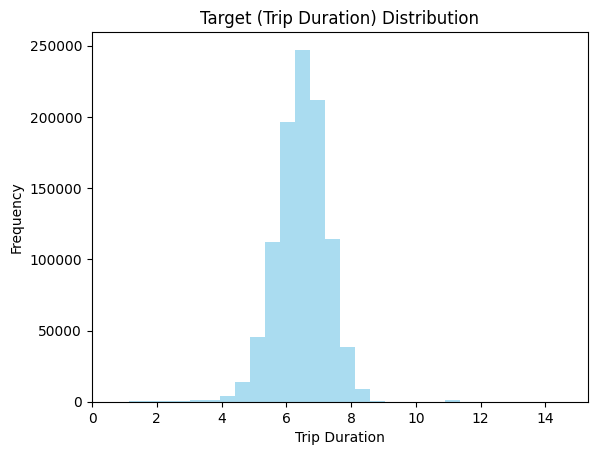

In [114]:
#Target (trip_duration) distribution  , draw the histogram
plt.hist(target_train_value, bins=30, color="skyblue", alpha=0.7)
plt.title("Target (Trip Duration) Distribution")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.show()

Target (trip_duration) distribution VS all features   using corr Matrix


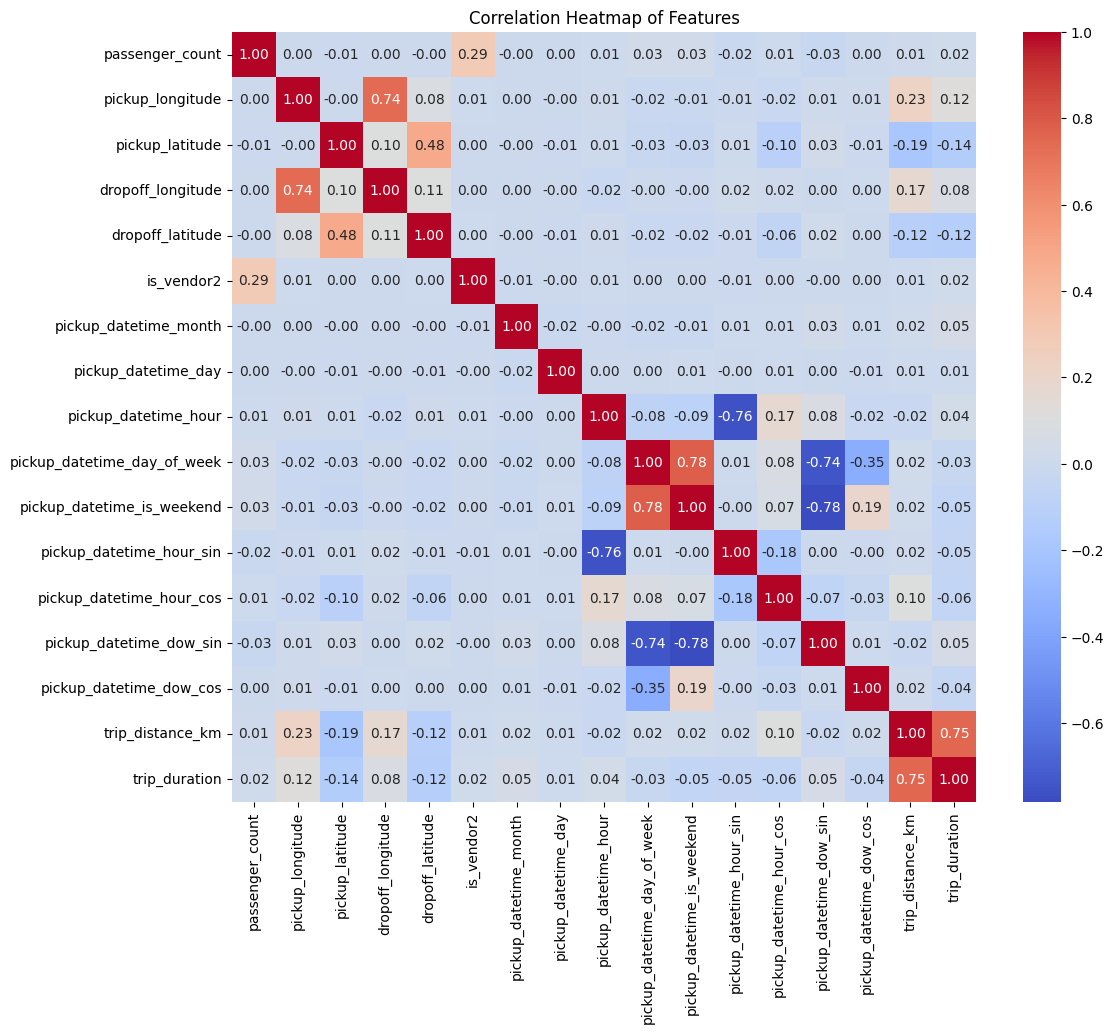

In [115]:
#Compute correlation matrix between features and target variable
df=pd.concat([train_data_copy, target_train_value.rename("trip_duration")], axis=1)
corr=df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()




After reviwing the corr Matrix

In [116]:
# features to drop based on correlation heatmap analysis
drop_features = [
    "pickup_datetime_is_weekend", # redundant (derived from day_of_week)
    "pickup_datetime_month",      # likely noise
    "pickup_datetime_day"         # likely noise
]

# drop from train and validation
train_data_copy = train_data_copy.drop(columns=drop_features, errors="ignore")
val_data_copy = val_data_copy.drop(columns=drop_features, errors="ignore")

In [117]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   is_vendor2                   999960 non-null  int64  
 6   pickup_datetime_hour         999960 non-null  int32  
 7   pickup_datetime_day_of_week  999960 non-null  int32  
 8   pickup_datetime_hour_sin     999960 non-null  float64
 9   pickup_datetime_hour_cos     999960 non-null  float64
 10  pickup_datetime_dow_sin      999960 non-null  float64
 11  pickup_datetime_dow_cos      999960 non-null  float64
 12  trip_distance_km             999960 non-null  float64
dtypes: f

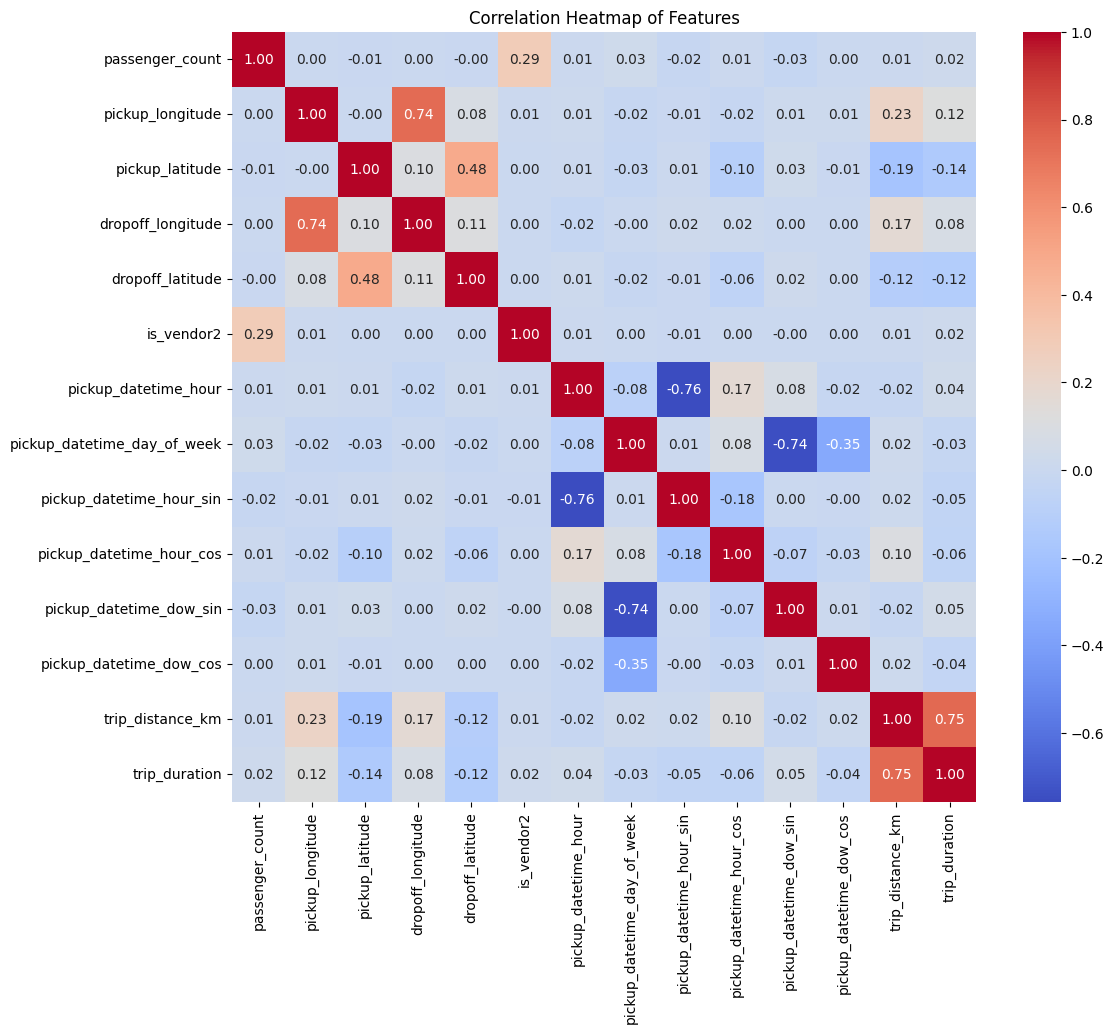

In [118]:
#Compute correlation matrix between features and target variable
df=pd.concat([train_data_copy, target_train_value.rename("trip_duration")], axis=1)
corr=df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()


In [119]:
import numpy as np

def add_rush_hour_features(df):
    # Rush hour basic binary
    df["is_rush_hour"] = df["pickup_datetime_hour"].isin([7,8,9,16,17,18]).astype(int)

    # Weekday rush (Mon–Fri)
    df["is_weekday_rush"] = (
        (df["pickup_datetime_day_of_week"].isin([0,1,2,3,4])) &
        (df["pickup_datetime_hour"].isin([7,8,9,16,17,18]))
    ).astype(int)

    # Multi-level rush indicator (0=off-peak, 1=medium, 2=peak)
    df["rush_level"] = 0  # default off-peak

    df.loc[df["pickup_datetime_hour"].isin([6,10,15,19]), "rush_level"] = 1
    df.loc[
        (df["pickup_datetime_day_of_week"].isin([0,1,2,3,4])) &
        (df["pickup_datetime_hour"].isin([7,8,9,16,17,18])),
        "rush_level"
    ] = 2

    return df



In [120]:
add_rush_hour_features(train_data_copy)
add_rush_hour_features(val_data_copy)

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,is_vendor2,pickup_datetime_hour,pickup_datetime_day_of_week,pickup_datetime_hour_sin,pickup_datetime_hour_cos,pickup_datetime_dow_sin,pickup_datetime_dow_cos,trip_distance_km,is_rush_hour,is_weekday_rush,rush_level
0,1,-74.013916,40.713444,-73.993858,40.752510,0,16,6,-0.866025,-5.000000e-01,-0.781831,0.623490,1.733628,1,0,0
1,1,-74.005440,40.727306,-73.983063,40.734715,0,18,3,-1.000000,-1.836970e-16,0.433884,-0.900969,1.117632,1,1,2
2,1,-73.987587,40.749863,-73.986809,40.757549,0,21,5,-0.707107,7.071068e-01,-0.974928,-0.222521,0.619082,0,0,0
3,1,-73.973862,40.784153,-73.983025,40.774479,1,20,0,-0.866025,5.000000e-01,0.000000,1.000000,0.843194,0,0,0
4,1,-73.999916,40.733101,-74.008331,40.734177,0,10,3,0.500000,-8.660254e-01,0.433884,-0.900969,0.541783,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229314,1,-73.988518,40.737137,-73.983948,40.765041,0,22,4,-0.500000,8.660254e-01,-0.433884,-0.900969,1.417461,0,0,0
229315,2,-74.006371,40.733372,-73.975792,40.782909,1,22,1,-0.500000,8.660254e-01,0.781831,0.623490,1.957376,0,0,0
229316,1,-74.013237,40.716980,-74.001297,40.734604,0,16,5,-0.866025,-5.000000e-01,-0.974928,-0.222521,1.164054,1,0,0
229317,1,-73.978394,40.748280,-73.982002,40.736580,1,19,1,-0.965926,2.588190e-01,0.781831,0.623490,0.848439,0,0,1


In [121]:
def add_distance_interactions(df):
    """
    Add interaction features with trip_distance_km
    """
    # Distance × Vendor
    df["dist_vendor2"] = df["trip_distance_km"] * df["is_vendor2"]

    # Distance × Passenger count
    df["dist_passenger"] = df["trip_distance_km"] * df["passenger_count"]

    # Distance × Time of day (sin/cos)
    df["dist_hour_sin"] = df["trip_distance_km"] * df["pickup_datetime_hour_sin"]
    df["dist_hour_cos"] = df["trip_distance_km"] * df["pickup_datetime_hour_cos"]

    # Distance × Day of week (sin/cos)
    df["dist_dow_sin"] = df["trip_distance_km"] * df["pickup_datetime_dow_sin"]
    df["dist_dow_cos"] = df["trip_distance_km"] * df["pickup_datetime_dow_cos"]

    # Differences in coordinates
    df["diff_long"] = df["dropoff_longitude"] - df["pickup_longitude"]
    df["diff_lat"] = df["dropoff_latitude"] - df["pickup_latitude"]

    # Interactions with distance
    df["dist_x_vendor"] = df["trip_distance_km"] * df["is_vendor2"]
    df["dist_x_passenger"] = df["trip_distance_km"] * df["passenger_count"]

    # Interactions with coordinate differences
    df["dist_x_diff_long"] = df["trip_distance_km"] * df["diff_long"]
    df["dist_x_diff_lat"] = df["trip_distance_km"] * df["diff_lat"]

    
    df["dist_pow_2"]= df["trip_distance_km"] * df["trip_distance_km"] 
    df["dist_pow_2_pass"]=  df["dist_pow_2"] *df["passenger_count"]
    df["dit_2_vendor"]= df["dist_pow_2"]* df["is_vendor2"]
    df["dist_pow_3"]= df["trip_distance_km"] * df["trip_distance_km"]  * df["trip_distance_km"]


    df["dist_hour_cos"]= df["dist_hour_cos"]* df["dist_hour_cos"]



    return df


In [122]:
add_distance_interactions(train_data_copy)
add_distance_interactions(val_data_copy)

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,is_vendor2,pickup_datetime_hour,pickup_datetime_day_of_week,pickup_datetime_hour_sin,pickup_datetime_hour_cos,...,diff_long,diff_lat,dist_x_vendor,dist_x_passenger,dist_x_diff_long,dist_x_diff_lat,dist_pow_2,dist_pow_2_pass,dit_2_vendor,dist_pow_3
0,1,-74.013916,40.713444,-73.993858,40.752510,0,16,6,-0.866025,-5.000000e-01,...,0.020058,0.039066,0.000000,1.733628,0.034773,0.067726,3.005465,3.005465,0.000000,5.210358
1,1,-74.005440,40.727306,-73.983063,40.734715,0,18,3,-1.000000,-1.836970e-16,...,0.022377,0.007408,0.000000,1.117632,0.025009,0.008280,1.249102,1.249102,0.000000,1.396037
2,1,-73.987587,40.749863,-73.986809,40.757549,0,21,5,-0.707107,7.071068e-01,...,0.000778,0.007687,0.000000,0.619082,0.000482,0.004759,0.383263,0.383263,0.000000,0.237271
3,1,-73.973862,40.784153,-73.983025,40.774479,1,20,0,-0.866025,5.000000e-01,...,-0.009163,-0.009674,0.843194,0.843194,-0.007726,-0.008157,0.710977,0.710977,0.710977,0.599491
4,1,-73.999916,40.733101,-74.008331,40.734177,0,10,3,0.500000,-8.660254e-01,...,-0.008415,0.001076,0.000000,0.541783,-0.004559,0.000583,0.293529,0.293529,0.000000,0.159029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229314,1,-73.988518,40.737137,-73.983948,40.765041,0,22,4,-0.500000,8.660254e-01,...,0.004570,0.027905,0.000000,1.417461,0.006478,0.039554,2.009195,2.009195,0.000000,2.847956
229315,2,-74.006371,40.733372,-73.975792,40.782909,1,22,1,-0.500000,8.660254e-01,...,0.030579,0.049538,1.957376,3.914752,0.059854,0.096964,3.831322,7.662643,3.831322,7.499338
229316,1,-74.013237,40.716980,-74.001297,40.734604,0,16,5,-0.866025,-5.000000e-01,...,0.011940,0.017624,0.000000,1.164054,0.013899,0.020515,1.355023,1.355023,0.000000,1.577320
229317,1,-73.978394,40.748280,-73.982002,40.736580,1,19,1,-0.965926,2.588190e-01,...,-0.003609,-0.011700,0.848439,0.848439,-0.003062,-0.009926,0.719848,0.719848,0.719848,0.610747


In [123]:
# from sklearn.preprocessing import PolynomialFeatures
# import pandas as pd

# selected_cols = ["trip_distance_km", "pickup_datetime_hour_sin", "pickup_datetime_hour_cos"]

# type(train_data_copy)
# # Slice only the selected columns
# X_train_selected = train_data_copy[selected_cols]
# X_val_selected = val_data_copy[selected_cols]

# poly = PolynomialFeatures(degree=2, include_bias=False)

# # Fit on training selected cols
# X_train_poly = poly.fit_transform(X_train_selected)
# X_val_poly = poly.transform(X_val_selected)

# # Convert back to DataFrame with names
# poly_features = poly.get_feature_names_out(selected_cols)
# train_data_copy = pd.DataFrame(X_train_poly, columns=poly_features, index=train_data_copy.index)
# val_data_copy = pd.DataFrame(X_val_poly, columns=poly_features, index=val_data_copy.index)



In [124]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   is_vendor2                   999960 non-null  int64  
 6   pickup_datetime_hour         999960 non-null  int32  
 7   pickup_datetime_day_of_week  999960 non-null  int32  
 8   pickup_datetime_hour_sin     999960 non-null  float64
 9   pickup_datetime_hour_cos     999960 non-null  float64
 10  pickup_datetime_dow_sin      999960 non-null  float64
 11  pickup_datetime_dow_cos      999960 non-null  float64
 12  trip_distance_km             999960 non-null  float64
 13  is_r

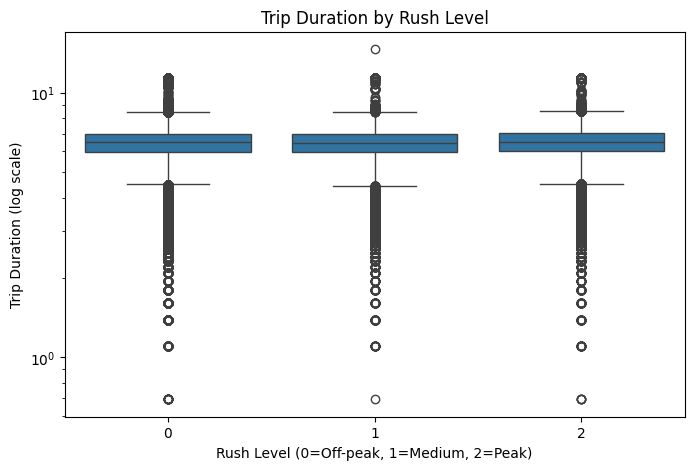

rush_level
0    6.451526
1    6.455125
2    6.516296
Name: trip_duration, dtype: float64


In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
#Compute correlation matrix between features and target variable
df=pd.concat([train_data_copy, target_train_value.rename("trip_duration")], axis=1)

# Boxplot trip_duration vs rush_level
plt.figure(figsize=(8,5))
sns.boxplot(x="rush_level", y="trip_duration", data=df)
plt.yscale("log")   # durations skewed → log scale is clearer
plt.title("Trip Duration by Rush Level")
plt.xlabel("Rush Level (0=Off-peak, 1=Medium, 2=Peak)")
plt.ylabel("Trip Duration (log scale)")
plt.show()

# Mean durations
print(df.groupby("rush_level")["trip_duration"].mean())


In [126]:
# Q1 = target_train_value.quantile(0.25)
# Q3 = target_train_value.quantile(0.75)
# IQR = Q3 - Q1

# # Outlier thresholds
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# mask = (target_train_value >= lower) & (target_train_value <= upper)

# # Filter data
# train_data_copy= train_data_copy[mask]
# target_train_value = target_train_value[mask]

# # this increases the performance from 63 to 66   and make overfitting


In [127]:
val_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229304 entries, 0 to 229318
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              229304 non-null  int64  
 1   pickup_longitude             229304 non-null  float64
 2   pickup_latitude              229304 non-null  float64
 3   dropoff_longitude            229304 non-null  float64
 4   dropoff_latitude             229304 non-null  float64
 5   is_vendor2                   229304 non-null  int64  
 6   pickup_datetime_hour         229304 non-null  int32  
 7   pickup_datetime_day_of_week  229304 non-null  int32  
 8   pickup_datetime_hour_sin     229304 non-null  float64
 9   pickup_datetime_hour_cos     229304 non-null  float64
 10  pickup_datetime_dow_sin      229304 non-null  float64
 11  pickup_datetime_dow_cos      229304 non-null  float64
 12  trip_distance_km             229304 non-null  float64
 13  is_r

In [128]:
# # Filter by correlation
# def correlation_filter(df, target, threshold=0.2):
#     corr_with_target = df.corr(numeric_only=True)[target].drop(target)
#     selected = corr_with_target[abs(corr_with_target) >= threshold].index.tolist()
#     return selected



In [129]:
# # drop highly correlated features
# def drop_high_corr(df, threshold=0.9):
#     corr_matrix = df.corr(numeric_only=True)
#     upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#     to_drop = [column for column in upper.columns if any(abs(upper[column]) > threshold)]
#     return df.drop(columns=to_drop), to_drop

In [130]:
# # Apply correlation filter
# df=pd.concat([train_data_copy, target_train_value.rename("trip_duration")], axis=1)
# selected_features = correlation_filter(df, "trip_duration", threshold=0.1)
# train_data_copy = train_data_copy[selected_features]
# val_data_copy= val_data_copy[selected_features]



In [131]:
# train_data_copy, dropped_cols = drop_high_corr(train_data_copy, threshold=0.9)

In [132]:
# val_data_copy,drop_cols=drop_high_corr(val_data_copy,threshold=0.9)

 Feature Interactions and Polynomial Features

In [133]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

def add_poly_features(df, strong_features, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    # Fit and transform only selected features
    poly_array = poly.fit_transform(df[strong_features])
    poly_names = poly.get_feature_names_out(strong_features)
    
    # Make DataFrame for new poly features
    poly_df = pd.DataFrame(poly_array, columns=poly_names, index=df.index)
    
    # Drop the originals if you don’t want duplication
    df = df.drop(columns=strong_features)
    
    # Add back expanded features
    df = pd.concat([df, poly_df], axis=1)
    
    return df




In [134]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999960 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   passenger_count              999960 non-null  int64  
 1   pickup_longitude             999960 non-null  float64
 2   pickup_latitude              999960 non-null  float64
 3   dropoff_longitude            999960 non-null  float64
 4   dropoff_latitude             999960 non-null  float64
 5   is_vendor2                   999960 non-null  int64  
 6   pickup_datetime_hour         999960 non-null  int32  
 7   pickup_datetime_day_of_week  999960 non-null  int32  
 8   pickup_datetime_hour_sin     999960 non-null  float64
 9   pickup_datetime_hour_cos     999960 non-null  float64
 10  pickup_datetime_dow_sin      999960 non-null  float64
 11  pickup_datetime_dow_cos      999960 non-null  float64
 12  trip_distance_km             999960 non-null  float64
 13  is_r

In [135]:
poly_features = [
    "trip_distance_km",
    "dist_vendor2",
    "dist_passenger",
    "dist_hour_sin",
    "dist_hour_cos",
    "rush_level",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]
train_data_copy = add_poly_features(train_data_copy, poly_features, degree=2)
val_data_copy = add_poly_features(val_data_copy, poly_features, degree=2)

In [136]:
strong_features=["trip_distance_km"]
train_data_copy = add_poly_features(train_data_copy, strong_features, degree=3)
val_data_copy = add_poly_features(val_data_copy, strong_features, degree=3)

In [137]:
train_data_copy["log-dis"]=np.log1p(train_data_copy["trip_distance_km"])
val_data_copy["log-dis"]=np.log1p(val_data_copy["trip_distance_km"])


This is the summary of all the feature_engineering that I did based on EDA analysis:


In [138]:
def feature_engineering(df):
    df = df.copy()
    
    # Log-transform target if present
    if "trip_duration" in df.columns:
        df["trip_duration"] = np.log1p(df["trip_duration"])

    # Vendor binary encoding
    if "vendor_id" in df.columns:
        df["is_vendor2"] = (df["vendor_id"] == 2).astype(int)
        df = df.drop(columns="vendor_id")

    # Drop irrelevant features
    df = df.drop(columns=[c for c in ["id", "store_and_fwd_flag"] if c in df.columns], errors="ignore")

    # Passenger count (cap instead of drop)
    if "passenger_count" in df.columns:
        df["passenger_count"] = df["passenger_count"].clip(1, 6)

    # Datetime features
    if "pickup_datetime" in df.columns:
        df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
        df["pickup_datetime_hour"] = df["pickup_datetime"].dt.hour
        df["pickup_datetime_day_of_week"] = df["pickup_datetime"].dt.dayofweek
        # Cyclical encoding
        df["pickup_datetime_hour_sin"] = np.sin(2 * np.pi * df["pickup_datetime_hour"] / 24)
        df["pickup_datetime_hour_cos"] = np.cos(2 * np.pi * df["pickup_datetime_hour"] / 24)
        df["pickup_datetime_dow_sin"] = np.sin(2 * np.pi * df["pickup_datetime_day_of_week"] / 7)
        df["pickup_datetime_dow_cos"] = np.cos(2 * np.pi * df["pickup_datetime_day_of_week"] / 7)
        df = df.drop(columns="pickup_datetime")

    # Haversine distance
    def haversine_distance(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        return 2 * np.arcsin(np.sqrt(a)) * 6371

    if all(col in df.columns for col in ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"]):
        df["trip_distance_km"] = haversine_distance(
            df["pickup_latitude"], df["pickup_longitude"],
            df["dropoff_latitude"], df["dropoff_longitude"]
        )
        df["log_trip_distance"] = np.log1p(df["trip_distance_km"])

    # Rush hour features
    if {"pickup_datetime_hour", "pickup_datetime_day_of_week"}.issubset(df.columns):
        df["is_rush_hour"] = df["pickup_datetime_hour"].isin([7,8,9,16,17,18]).astype(int)
        df["is_weekday_rush"] = (
            df["pickup_datetime_day_of_week"].isin([0,1,2,3,4]) &
            df["pickup_datetime_hour"].isin([7,8,9,16,17,18])
        ).astype(int)
        df["rush_level"] = 0
        df.loc[df["pickup_datetime_hour"].isin([6,10,15,19]), "rush_level"] = 1
        df.loc[
            (df["pickup_datetime_day_of_week"].isin([0,1,2,3,4])) &
            (df["pickup_datetime_hour"].isin([7,8,9,16,17,18])),
            "rush_level"
        ] = 2

    # Distance interactions
    if "trip_distance_km" in df.columns:
        if "is_vendor2" in df.columns:
            df["dist_vendor2"] = df["trip_distance_km"] * df["is_vendor2"]
        if "passenger_count" in df.columns:
            df["dist_passenger"] = df["trip_distance_km"] * df["passenger_count"]
        if "pickup_datetime_hour_sin" in df.columns:
            df["dist_hour_sin"] = df["trip_distance_km"] * df["pickup_datetime_hour_sin"]

        # Add more interactions as needed ...

    # Drop weak features
    drop_features = ["pickup_datetime_month", "pickup_datetime_day"]
    df = df.drop(columns=[f for f in drop_features if f in df.columns], errors="ignore")

    return df


In [139]:
from sklearn.pipeline import FunctionTransformer


feature_engineering_transformer = FunctionTransformer(feature_engineering, validate=False)

# Apply transformation:
transformed_train = feature_engineering_transformer.fit_transform(train_data_copy)
transformed_val = feature_engineering_transformer.transform(val_data_copy)

Scaling using MinMax scaler

In [140]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
train_data_copy_scaled=scaler.fit_transform(transformed_train)
val_data_copy_scaled=scaler.transform(transformed_val)

Baseline Model

In [141]:
from sklearn.linear_model import Ridge
X_train=train_data_copy_scaled
y_train=target_train_value
X_val=val_data_copy_scaled
y_val=target_val_value

rd=Ridge(alpha=1, random_state=14)
rd.fit(X_train, y_train)
y_train_prediction=rd.predict(X_train)

y_val_pred=rd.predict(X_val)


Evaluate the model based on r2_score

In [142]:
from sklearn.metrics import r2_score
r2_train=r2_score(y_train,y_train_prediction )
r2_val=r2_score(y_val, y_val_pred) # Evaluate the model based on r2_score
print(f"RidgeRegression R² (Train): {r2_train *100}")
print(f"RidgeRegression R² (Validation): {r2_val *100}")

RidgeRegression R² (Train): 63.79842585342232
RidgeRegression R² (Validation): 63.841739118094964


In [143]:
from sklearn.metrics import mean_squared_log_error
r2_train=mean_squared_log_error(y_train,y_train_prediction )
r2_val=mean_squared_log_error(y_val, y_val_pred) # Evaluate the model based on r2_score
print(f"RidgeRegression R² (Train): {np.sqrt(r2_train)}")
print(f"RidgeRegression R² (Validation): {np.sqrt(r2_val)}")

RidgeRegression R² (Train): 0.06988420446197584
RidgeRegression R² (Validation): 0.0704795527987695


let's try Random Forest (non linear model)

In [144]:
# from sklearn.ensemble import RandomForestRegressor
# rf = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# y_train_prediction= rf.predict(X_train)
# y_pred_rf_val=rf.predict(X_val)

# r2_train_rf=r2_score(y_train, y_train_prediction)
# r2_val_rf=r2_score(y_val, y_pred_rf_val) # Evaluate the model based on r2_score

# print(f"RandomForest R² (Train): {r2_train_rf *100}")
# print(f"RandomForest R² (Validation): {r2_val_rf *100}")


In [145]:
# from sklearn.ensemble import GradientBoostingRegressor
# gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
# gbr.fit(X_train, y_train)

# y_train_prediction_gbr= gbr.predict(X_train)
# r2_train_gbr=r2_score(y_train, y_train_prediction_gbr)
# y_pred_gbr = gbr.predict(X_val)
# r2_val_gbr=r2_score(y_val, y_pred_gbr) # Evaluate the model based on r2_score
# print(f"GradientBoosting R² (Validation): {r2_val_gbr *100}")
# print(f"GradientBoosting R² (Train): {r2_train_gbr *100}")

In [146]:
#XGBoost
import xgboost as xgb
xgbr = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
xgbr.fit(X_train, y_train)
y_train_prediction_xgb= xgbr.predict(X_train)
r2_train_xgb=r2_score(y_train, y_train_prediction_xgb)
y_pred_xgb = xgbr.predict(X_val)
r2_val_xgb=r2_score(y_val, y_pred_xgb) # Evaluate the model based on r2_score
print(f"XGBoost R² (Validation): {r2_val_xgb *100}")
print(f"XGBoost R² (Train): {r2_train_xgb *100}")


XGBoost R² (Validation): 72.43379228307634
XGBoost R² (Train): 72.91283231633075


Feature Importance Visualization

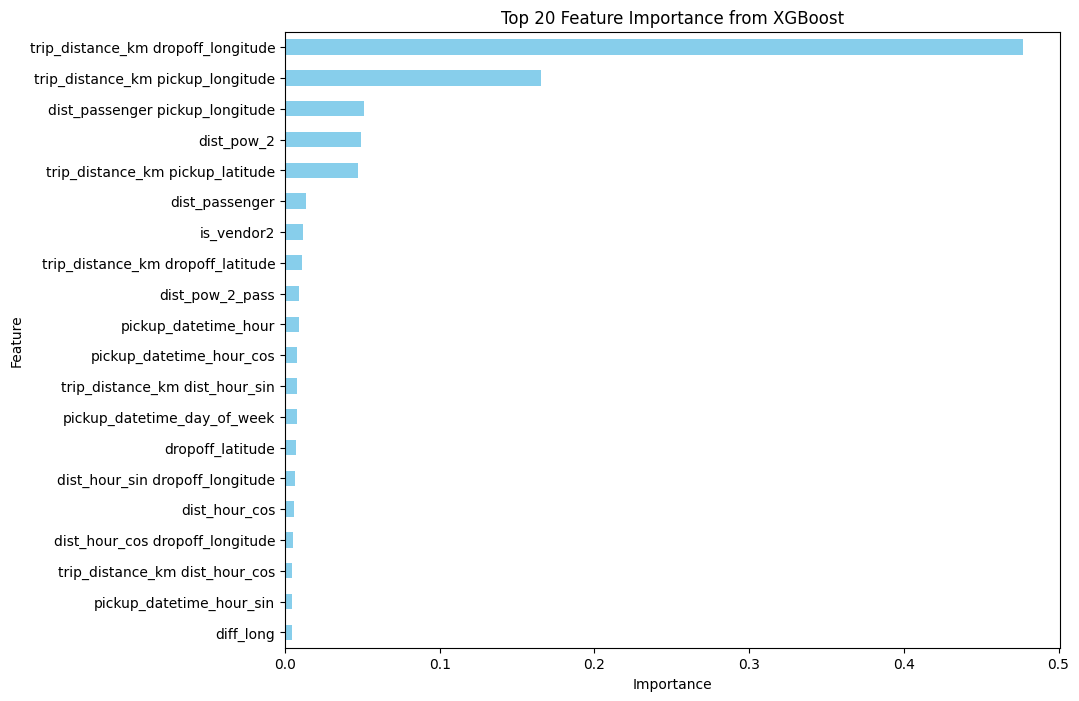

In [150]:
# Display only the top 20 most important features
top_n = 20
top_features = feat_importance_df.tail(top_n)

top_features.plot(kind='barh', x='feature', y='importance', legend=False, figsize=(10, 8), color='skyblue', title='Top 20 Feature Importance from XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
# features_importance = rf.feature_importances_
# # Create a DataFrame
# feat_importance_df = pd.DataFrame({
#     'feature': train_data_copy.columns,
#     'importance': features_importance
# })
# # Sort descending
# feat_importance_df = feat_importance_df.sort_values(by='importance', ascending=True)

# feat_importance_df.plot(kind='barh', x='feature', y='importance', legend=False, figsize=(10, 8), color='skyblue', title='Feature Importance from XGBoost')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()

In [ ]:
# features_importance = gbr.feature_importances_
# # Create a DataFrame
# feat_importance_df = pd.DataFrame({
#     'feature': train_data_copy.columns,
#     'importance': features_importance
# })
# # Sort descending
# feat_importance_df = feat_importance_df.sort_values(by='importance', ascending=True)

# feat_importance_df.plot(kind='barh', x='feature', y='importance', legend=False, figsize=(10, 8), color='skyblue', title='Feature Importance from XGBoost')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()